### Deep Convolutional Generative Adversarial Network (GAN)

The idea is to make the GAN learn on simulated 2D spectra (**GELSA**)

The architecture of a GAN is **generator** + **discriminator**. We'll be implementing an *attention-gated U-Net* as generator.


In [27]:
import glob
import imageio
from IPython import display
import tensorflow as tf
import tensorflow.keras.layers as L
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import time
import os
from tensorflow.keras.models import Model


In [4]:
# In each learning step we're passing multiple "batches" to the GAN. 
# The BATCH_SIZE defines the size of each batch, hence the number of batches
# BUFFER_SIZE must me >= number of images in the training set.

BUFFER_SIZE = 6000
BATCH_SIZE = 16

In [5]:
hdu_rect = fits.open("/scratch/astro/nicolo.fiaba/training_sets/labels_RGS180_4.fits", memmap=True)
hdu_rect_masked = fits.open("/scratch/astro/nicolo.fiaba/training_sets/train_RGS180_4.fits", memmap=True)

In [6]:
img_data = np.array([hdu.data for hdu in hdu_rect[1:]])
img_data_masked = np.array([hdu.data for hdu in hdu_rect_masked[1:]])

In [7]:
""" Mask object: 
- 0: Existing pixel
- 1: Missing pixel
"""
mask = np.isnan(img_data_masked).astype(np.float32)

#### Setting a threshold to the flux value in each pixel:
> Whenever a pixel exceeds the flux value of 16000, its value is set back to 16000

In [8]:
max_threshold = 16000 
"""
This was suggested by Savio. 
Ask again why, because looking at real data this doesn't seem to be the pixels maximum value. Anyway..
"""
img_data[img_data > max_threshold] = max_threshold
img_data_masked[img_data_masked > max_threshold] = max_threshold

### Add gaussian noise to the spectra ($\sigma = \sqrt{800}$)

In [9]:
# Noise
sigma = np.sqrt(800)
size = (len(img_data), 512, 512)
noise = np.random.normal(loc=0, scale=sigma, size=size)

In [10]:
img_noise = img_data + noise
img_noise_masked = img_data_masked + noise

img_noise = np.array(img_noise, dtype=np.float32)
img_noise_masked = np.array(img_noise_masked, dtype=np.float32)

### Rescaling images

In ML it's crucial to renormalize the data in the (0, 1) range or (-1, 1). 

Everything is **rescaled** with the **same factor**, the maximum flux is the images with emission lines (since they are the brightest).

**NB**: The mask dataset is already normalized [0, 1]

In [16]:
# Image normalization -> (0,1)
x_max = np.nanmax(img_noise)
x_min = np.nanmin(img_noise)
rescale = L.Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))

In [17]:
img_noise = rescale(img_noise)
img_noise_masked = rescale(img_noise_masked)

# Converting to numpy, otherwise train_test_split function won't work
img_noise = img_noise.numpy()
img_noise_masked = img_noise_masked.numpy()

#### We stack the **masked images** and the **masks** themselves: 
These will be the inputs of the network: $(512, 512, 2)$

In [18]:
input_imgs = np.stack([img_noise_masked, mask], axis=-1)

### Train and test set split

In [64]:
from sklearn.model_selection import train_test_split

# test set is 10% of the whole dataset
x_train, x_test, y_train, y_test = train_test_split(
    img_noise_masked, img_noise, test_size=0.1, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42)

x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_val = tf.convert_to_tensor(x_val, dtype=tf.float32)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)

y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

In [65]:
# Set NaNs to 0 before feeding the U-Net
x_train = tf.where(tf.math.is_nan(x_train), 0., x_train)
x_val = tf.where(tf.math.is_nan(x_val), 0., x_val)
x_test = tf.where(tf.math.is_nan(x_test), 0., x_test)

image_size = (x_train.shape[1], x_train.shape[2])

In [66]:
print("Images in training set:", len(x_train),
      "\nImages in validation set:", len(x_val),
      "\nImages in test set:", len(x_test),
      "\nImage size:", image_size)

Images in training set: 3386 
Images in validation set: 847 
Images in test set: 471 
Image size: (512, 512)


In [67]:
BATCH_SIZE = 2

train_dataset = tf.data.Dataset.from_tensor_slices((x_train[:10], y_train[:10])).batch(BATCH_SIZE)#.shuffle(100)
val_dataset = tf.data.Dataset.from_tensor_slices((x_val[:10], y_val[:10])).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test[:10], y_test[:10])).batch(BATCH_SIZE)

---

Let's try to train a GAN to inpaint Euclid-like 2D spectra

### Build the generator (Attention-gated U-Net)

In [68]:
# Necessary blocks for the attention-gated UNET

def conv_block(x, num_filters):
    x = L.Conv2D(num_filters, 3, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    x = L.Conv2D(num_filters, 3, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)

    return x

def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = L.MaxPool2D((2,2))(x)
    return x, p

def attention_gate(g, s, num_filters):
    Wg = L.Conv2D(num_filters, 1, padding='same')(g)
    Wg = L.BatchNormalization()(Wg)

    Ws = L.Conv2D(num_filters, 1, padding='same')(s)
    Ws = L.BatchNormalization()(Ws)

    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(num_filters, 1, padding='same')(out)
    out = L.Activation('sigmoid')(out)

    return out * s

def decoder_block(x, s, num_filters):
    x = L.UpSampling2D(interpolation='bilinear')(x)
    s = attention_gate(x, s, num_filters)
    x = L.Concatenate()([x, s])
    x = conv_block(x, num_filters)
    return x

In [69]:
# Autoencoder used as a generator for the inpainting task

def build_generator(image_size):
    """ Inputs """
    inputs = L.Input(shape=(image_size[0], image_size[1], 1))

    """ Encoder """
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    """ Bridge / Bottleneck """
    b1 = conv_block(p4, 1024)

    """ Decoder """
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    """ Outputs """
    outputs = L.Conv2D(1, 1, padding='same', activation='sigmoid')(d4)

    attention_unet_model = Model(inputs, outputs, name='Attention-UNET')
    return attention_unet_model 

In [70]:
generator = build_generator(image_size)

Trick to go back to the original (10, 500) shape

### Build the discriminator

In [114]:
# Conv2D is "downscaling" the image
# This is just a simple "binary classifier"
def build_discriminator():
    inputs = L.Input(shape=(image_size[0], image_size[1], 1))
    x = L.Conv2D(64, 3, strides=2, padding='same')(inputs)
    x = L.LeakyReLU(0.2)(x)

    x = L.Conv2D(128, 3, strides=2, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.LeakyReLU(0.2)(x)

    x = L.Conv2D(256, 3, strides=2, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.LeakyReLU(0.2)(x)

    x = L.Conv2D(512, 3, strides=2, padding='same')(x)
    x = L.BatchNormalization()(x)
    x = L.LeakyReLU(0.2)(x)

    x = L.Flatten()(x)
    outputs = L.Dense(1, activation='sigmoid')(x)

    discriminator = Model(inputs, outputs, name='Discriminator')

    return discriminator

In [115]:
discriminator = build_discriminator()

In [116]:
discriminator.summary()

Model: "Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 512, 512, 1)]     0         
                                                                 
 conv2d_140 (Conv2D)         (None, 256, 256, 64)      640       
                                                                 
 leaky_re_lu_16 (LeakyReLU)  (None, 256, 256, 64)      0         
                                                                 
 conv2d_141 (Conv2D)         (None, 128, 128, 128)     73856     
                                                                 
 batch_normalization_116 (B  (None, 128, 128, 128)     512       
 atchNormalization)                                              
                                                                 
 leaky_re_lu_17 (LeakyReLU)  (None, 128, 128, 128)     0         
                                                     

We need to train the GAN: training the generator and discriminator side by side.

We can't use the **.fit** method. We need to write our own training loop (step)

### Training loop

We need a custom loss function for the GAN: One for the generator, one for the discriminator

In [117]:
# Optimizer
from tensorflow.keras.optimizers import Adam
# Loss function
from tensorflow.keras.losses import BinaryCrossentropy, MeanAbsoluteError

We'll be basically rewarding the generator for tricking the discriminator and rewarding the discriminator for determining the correct type of image: fake (reconstructed) or real (original)

In [118]:
# g for generator
g_opt = Adam(learning_rate=0.0001)
# d for discriminator
d_opt = Adam(learning_rate=0.00001) # NB

g_loss = MeanAbsoluteError()
d_loss = BinaryCrossentropy()

#### We now need to build a subclassed model

The idea is to modify the original class and change the **.fit** method as we wish.

In [119]:
# Importing the base model class to subclass our training step
from tensorflow.keras.models import Model

In [126]:
class FashionGAN(Model):
    def __init__(self, generator, discriminator, *args, **kwargs):
        # Here we're inheriting args and kwargs from base class (Keras Model)
        super().__init__(*args, **kwargs) 

        # Create attributes for gen and discr
        self.generator = generator
        self.discriminator = discriminator
  
    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
        super().compile(*args, **kwargs)

        # Create attributes for losses and optimizers
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss

    # train_step takes a batch of data
    def train_step(self, data): # this is called when you call the .fit method
        # Get data
        original_images, masked_images = data
        reconstructed_images = self.generator(masked_images, training=False)

        # Train the discriminator
        # We need to calculate the gradient
        with tf.GradientTape() as d_tape:
            # Pass the original and reconstructred images to discriminator
            yhat_origin = self.discriminator(original_images, training=True)
            yhat_recons = self.discriminator(reconstructed_images, training=True)
            yhat_orcons = tf.concat([yhat_origin, yhat_recons], axis=0)
            
            # Create labels for orig and reconst imgs (TRUE labels)
            y_orcons = tf.concat([tf.zeros_like(yhat_origin), tf.ones_like(yhat_recons)], axis=0)
            
            # Add noise to the TRUE outputs
            noise_origin = 0.15*tf.random.uniform(tf.shape(yhat_origin))
            noise_recons = -0.15*tf.random.uniform(tf.shape(yhat_recons))
            y_orcons += tf.concat([noise_origin, noise_recons], axis=0)
            
            # Calculate loss
            total_d_loss = self.d_loss(y_orcons, yhat_orcons)
            
        # Apply backprop: outside the "with" loop. First we calculate the gradient, then apply that using optimizers
        dgrad = d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables)) # d_opt is Adam optimizer

        # Train the generator
        with tf.GradientTape() as g_tape:
            # Generate reconstructed images
            gen_images = self.generator(masked_images, training=True)
            
            # Create predicted labels
            predicted_labels = self.discriminator(gen_images, training=False)
            
            # Calculate loss
            # We're implying that generated images are REAL and we reward the generator for faking out the discriminator
            total_g_loss = self.g_loss(tf.zeros_like(predicted_labels), predicted_labels)
            
        # Apply backpropagation
        ggrad = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))

        mae = tf.reduce_mean(tf.abs(tf.expand_dims(original_images, -1) - reconstructed_images))

        return {"d_loss": total_d_loss, "g_loss": total_g_loss, "recon_mae": mae}

In [127]:
# Create instance of subclassed model
fashgan = FashionGAN(generator, discriminator)

In [128]:
# Compile the model
fashgan.compile(g_opt, d_opt, g_loss, d_loss)

#### Build Callback

In [129]:
from tensorflow.keras.callbacks import Callback

Skip for now

---

In [130]:
hist = fashgan.fit(train_dataset, epochs=200)

Epoch 1/200


2025-11-18 11:36:27.976753: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'gradient_tape/Discriminator/leaky_re_lu_16/LeakyRelu/LeakyReluGrad' exist for missing node 'Discriminator/conv2d_140/BiasAdd'.


5/5 [==============================] - 19s 3s/step - d_loss: 0.4598 - g_loss: 0.4942 - recon_mae: 0.6372
Epoch 2/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.4574 - g_loss: 0.4782 - recon_mae: 0.3383
Epoch 3/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.6708 - g_loss: 0.4829 - recon_mae: 0.1720
Epoch 4/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.4596 - g_loss: 0.5100 - recon_mae: 0.1262
Epoch 5/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.6986 - g_loss: 0.5347 - recon_mae: 0.1023
Epoch 6/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.6683 - g_loss: 0.5694 - recon_mae: 0.1776
Epoch 7/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.5045 - g_loss: 0.5840 - recon_mae: 0.1623
Epoch 8/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.4055 - g_loss: 0.5707 - recon_mae: 0.1909
Epoch 9/200
5/5 [==============================] - 14s 3s/step - d_loss: 0.2

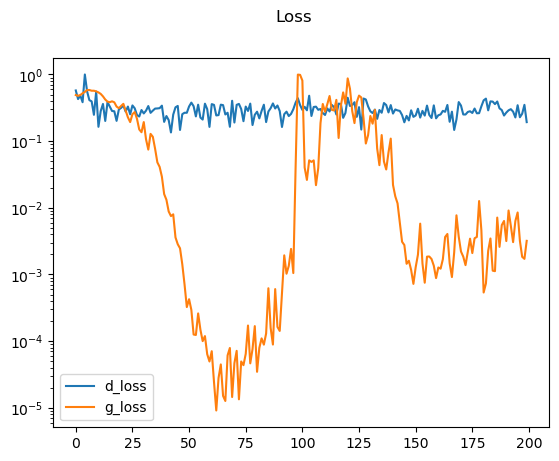

In [131]:
plt.suptitle("Loss")
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.yscale('log')
plt.legend()
plt.show()

In [132]:
img_predicted = generator.predict(train_dataset)

5/5 [==============================] - 3s 674ms/step


In [84]:
img_predicted.shape

(10, 512, 512, 1)

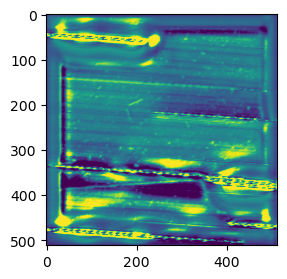

In [133]:
from gelsa import visu

plt.figure(figsize=(10,3))
plt.imshow(visu.normalize_image(img_predicted[1], levels=(5, 95)), aspect=1)